In [3]:
#importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt


#loading data 
dataset=load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


#Data Cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

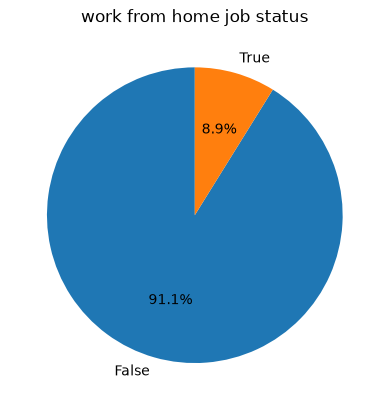

In [ ]:
#restart the session to run pie plot
df_plot= df['job_work_from_home'].value_counts()
df_plot.plot(kind='pie', startangle=90,autopct='%1.1f%%')
plt.title('work from home job status')
plt.show()

In [11]:
df[['job_work_from_home','job_no_degree_mention','job_health_insurance']]


,job_work_from_home,job_no_degree_mention,job_health_insurance
0,False,False,False
1,False,False,False
2,False,False,False
3,False,True,False
4,False,False,False
...,...,...,...
785736,False,False,False
785737,False,False,False
785738,False,False,False
785739,False,False,False


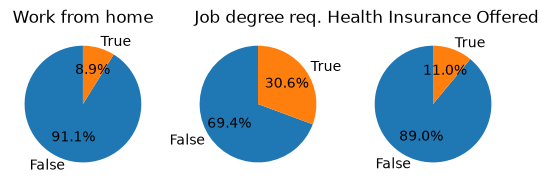

In [20]:
fig, ax = plt.subplots(1,3)
dict_column={'job_work_from_home':'Work from home',
             'job_no_degree_mention':'Job degree req.',
             'job_health_insurance':'Health Insurance Offered'
             }

for i,(column,title) in enumerate(dict_column.items()):
  ax[i].pie(df[column].value_counts(),startangle=90,autopct='%1.1f%%', labels=['False','True'])
  ax[i].set_title(title) 

plt.show()

In [4]:
#Restart the session to run the scatter plot

df=df[df['job_title_short']=='Data Analyst']


In [8]:
df_exploded = df.explode('job_skills')
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary = ('salary_year_avg','median')
)

#limit to top 20 skills
skill_count= 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)

skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


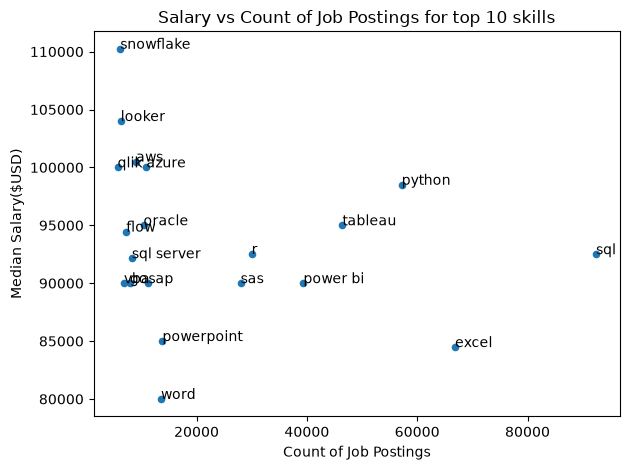

In [9]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Salary($USD)')
plt.title('Salary vs Count of Job Postings for top 10 skills')
plt.tight_layout()
for i, txt in enumerate(skill_stats.index): #for adding titles to scatter plot points
   plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)
plt.show()